# final report

### step1: 載入資料

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.model_selection import GridSearchCV


# Windows 內建支持中文的字體
# plt.rcParams['font.family'] = 'Microsoft JhengHei'
# plt.rcParams['axes.unicode_minus'] = False

# Mac 內建的支援中文的字體
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] 
# 或者是 plt.rcParams['font.sans-serif'] = ['PingFang TC']

# 解決負號 ('-') 顯示為方塊的問題
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 載入資料，切分資料(確認是不是要獨立切出一個驗證集)

# ── 1. 載入資料，排除序號欄 ────────────────────────────────
df = pd.read_csv('processed_data.csv')
df = df.drop(columns=['序號'])

# ── 2. 特徵與目標變數（Y 在最後，直接取欄名）──────────────
X = df.drop(columns=['Y_事故嚴重度']).fillna(0)
y = df['Y_事故嚴重度']

features = X.columns.tolist()
print(f"特徵數量：{len(features)}")
print(f"特徵清單：{features}")

# ── 3. 切分訓練集 / 測試集 ────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n訓練集 Y 分布：")
print(y_train.value_counts())
print(f"\n測試集 Y 分布：")
print(y_test.value_counts())
print(f"\n訓練集：{len(X_train)} 筆，測試集：{len(X_test)} 筆")

特徵數量：54
特徵清單：['GPS座標X', 'GPS座標Y', 'hour', 'is_morning_rush', 'is_night', 'is_weekend', 'month', 'time_period_daytime', 'time_period_evening_rush', 'time_period_late_night', 'time_period_morning_rush', 'time_period_night', 'weekday', '事故位置_1', '事故位置_8', '事故位置_9', '分向設施_1', '分向設施_10', '分向設施_5', '區_北屯區', '區_后里區', '區_大雅區', '區_東區', '區_梧棲區', '區_沙鹿區', '區_潭子區', '區_烏日區', '區_西屯區', '區_豐原區', '區_龍井區', '天候_5', '快慢車道間_4', '快慢車道間_5', '快車道或一般車道間_4', '快車道或一般車道間_5', '號誌動作_4', '號誌動作_缺失', '號誌種類_3', '號誌種類_4', '號誌種類_缺失', '路面狀態_4', '路面狀態_5', '路面邊線_1', '路面邊線_2', '道路型態_11', '道路型態_13', '道路型態_3', '道路型態_4', '道路型態_5', '道路照明設備_1', '道路照明設備_2', '道路照明設備_3', '道路速限', '道路類別_6']

訓練集 Y 分布：
Y_事故嚴重度
1    8580
0    6749
Name: count, dtype: int64

測試集 Y 分布：
Y_事故嚴重度
1    2146
0    1687
Name: count, dtype: int64

訓練集：15329 筆，測試集：3833 筆


## Logistic regression
### step 2: modeling

In [3]:
# 標準化資料

# 建立前處理器：把標準化放進 Pipeline，避免 cross-validation 時的資料洩漏

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ── 只對連續型欄位做標準化 ─────────────────────────────────
continuous_cols = ['GPS座標X', 'GPS座標Y', 'hour', 'month', 'weekday', '道路速限']

# 檢查連續欄位是否都存在，避免欄位名稱打錯導致後面報錯
missing_cols = [col for col in continuous_cols if col not in X_train.columns]
if len(missing_cols) > 0:
    raise ValueError(f"以下連續欄位不存在於 X_train 中：{missing_cols}")

# ColumnTransformer 會在每一次 fit / cross-validation 中，只用訓練資料估計平均數與標準差
preprocess = ColumnTransformer(
    transformers=[
        ('scale', StandardScaler(), continuous_cols)
    ],
    remainder='passthrough'
)

print("前處理器建立完成！")
print("會被標準化的連續欄位：")
print(continuous_cols)

前處理器建立完成！
會被標準化的連續欄位：
['GPS座標X', 'GPS座標Y', 'hour', 'month', 'weekday', '道路速限']


In [4]:
# 有 class_weight：使用 Pipeline 進行 Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# ── 1. 定義 Pipeline：標準化 + Logistic Regression ─────────
lr_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced',
        solver='liblinear'
    ))
])

# 為了讓後面若有用到 model 這個名稱也能跑，保留同義變數
model = lr_pipe

# ── 2. 交叉驗證：直接丟原始 X_train，不要先手動標準化 ───────
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_recall = cross_val_score(
    lr_pipe, X_train, y_train,
    cv=cv, scoring='recall', n_jobs=-1
)

cv_f1 = cross_val_score(
    lr_pipe, X_train, y_train,
    cv=cv, scoring='f1', n_jobs=-1
)

print("交叉驗證結果（訓練集）：")
print(f"  Recall : {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
print(f"  F1     : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

# ── 3. 訓練最終模型 ───────────────────────────────────────
lr_pipe.fit(X_train, y_train)
print("\n模型訓練完成！")

交叉驗證結果（訓練集）：
  Recall : 0.5330 ± 0.0224
  F1     : 0.5733 ± 0.0214

模型訓練完成！


### step3 : Hyperparameter

In [5]:
# 調超參數 Grid Search
# 注意：因為現在模型包在 Pipeline 裡，所以參數名稱前面要加 model__

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# ── 定義 Pipeline ─────────────────────────────────────────
lr_grid_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# ── 定義參數網格 ──────────────────────────────────────────
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear'],
    'model__class_weight': ['balanced', None]
}

# ── Grid Search：用 F1-score 作為挑選標準 ───────────────────
grid_search = GridSearchCV(
    lr_grid_pipe,
    param_grid,
    cv=10,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# 直接使用原始 X_train，標準化會在 Pipeline 裡面完成
grid_search.fit(X_train, y_train)

# ── 整理結果 ──────────────────────────────────────────────
results = pd.DataFrame(grid_search.cv_results_)

summary = results[[
    'param_model__C',
    'param_model__penalty',
    'param_model__class_weight',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]]

summary = summary.rename(columns={
    'param_model__C': 'C',
    'param_model__penalty': 'penalty',
    'param_model__class_weight': 'class_weight',
    'mean_test_score': 'F1-score（平均）',
    'std_test_score': 'F1-score（標準差）',
    'rank_test_score': '排名'
})

summary['F1-score（平均）'] = summary['F1-score（平均）'].round(4)
summary['F1-score（標準差）'] = summary['F1-score（標準差）'].round(4)

print("Grid Search 結果（以 F1-score 作為標準）：")
print(summary.sort_values('排名').to_string(index=False))

print("\n最佳參數：")
print(grid_search.best_params_)
print(f"最佳 F1-score（CV）：{grid_search.best_score_:.4f}")

Fitting 10 folds for each of 20 candidates, totalling 200 fits
Grid Search 結果（以 F1-score 作為標準）：
     C penalty class_weight  F1-score（平均）  F1-score（標準差）  排名
  0.01      l1          NaN        0.7138         0.0022   1
  0.10      l1          NaN        0.6882         0.0050   2
  0.01      l2          NaN        0.6871         0.0059   3
  0.10      l2          NaN        0.6811         0.0069   4
  1.00      l1          NaN        0.6806         0.0070   5
 10.00      l1          NaN        0.6801         0.0078   6
100.00      l1          NaN        0.6800         0.0078   7
 10.00      l2          NaN        0.6799         0.0079   8
100.00      l2          NaN        0.6799         0.0077   9
  1.00      l2          NaN        0.6799         0.0079  10
100.00      l1     balanced        0.5750         0.0068  11
  1.00      l1     balanced        0.5748         0.0084  12
  1.00      l2     balanced        0.5748         0.0068  13
100.00      l2     balanced        0.5748         

In [6]:
# ── 用 balanced 作為 LR 最終模型 ─────────────────
# 注意：現在 best_lr_model 是 Pipeline，裡面包含標準化與 Logistic Regression

best_lr_model = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(
        C=0.01,
        penalty='l2',
        solver='liblinear',
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ))
])

# 直接用原始 X_train 訓練，不要用 X_train_scaled
best_lr_model.fit(X_train, y_train)
print("LR 最終模型訓練完成！")

LR 最終模型訓練完成！


### step 4 : Evaluation

Logistic Regression 評估結果：
Accuracy  : 0.5638
Precision : 0.6299
Recall    : 0.5354
F1-score  : 0.5788
ROC-AUC   : 0.5947
PR-AUC    : 0.6341

Classification Report:
              precision    recall  f1-score   support

         非致命       0.50      0.60      0.55      1687
          致命       0.63      0.54      0.58      2146

    accuracy                           0.56      3833
   macro avg       0.57      0.57      0.56      3833
weighted avg       0.57      0.56      0.57      3833


Confusion Matrix:
[[1012  675]
 [ 997 1149]]


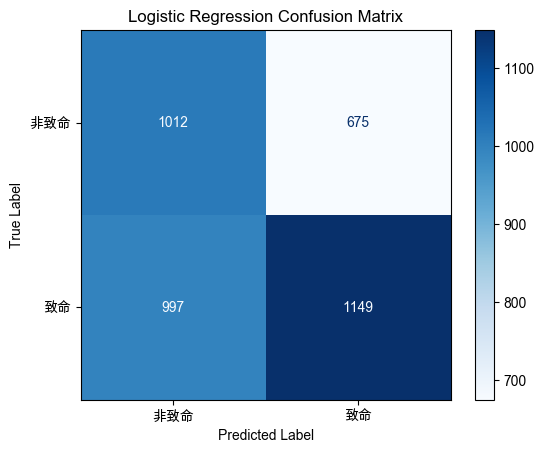

In [7]:
# 各項指標
# ── Logistic Regression 最終模型評估 ─────────────────────

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,ConfusionMatrixDisplay
)

# 預測類別與機率
y_pred = best_lr_model.predict(X_test)
y_prob = best_lr_model.predict_proba(X_test)[:, 1]

# 儲存 LR 評估指標，後面 RF 比較會用到
lr_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_prob),
    'PR-AUC': average_precision_score(y_test, y_prob)
}

print("Logistic Regression 評估結果：")
for metric, value in lr_metrics.items():
    print(f"{metric:<10}: {value:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['非致命', '致命']
))


# confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

cm_lr = confusion_matrix(y_test, y_pred)

disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=['非致命', '致命']
)

disp_lr.plot(cmap='Blues', values_format='d')

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [8]:
# LR 輸出機率值
lr_prob = best_lr_model.predict_proba(X_test)[:, 1]

lr_result = pd.DataFrame({
    'y_true': y_test.values,
    'y_prob': lr_prob
})

print(lr_result.head(10))
lr_result.to_csv('lr_prob.csv', index=False)

   y_true    y_prob
0       0  0.691051
1       1  0.522992
2       0  0.402291
3       0  0.436685
4       1  0.457936
5       0  0.553721
6       0  0.492505
7       0  0.397501
8       0  0.557974
9       0  0.581325


In [9]:
threshold = 0.4  # 可以調整這個數值

y_pred_lr_custom = (lr_prob >= threshold).astype(int)

from sklearn.metrics import classification_report, accuracy_score
print(f"門檻：{threshold}")
print(classification_report(y_test, y_pred_lr_custom, target_names=['non-fatal', 'fatal']))

門檻：0.4
              precision    recall  f1-score   support

   non-fatal       0.67      0.07      0.13      1687
       fatal       0.57      0.97      0.72      2146

    accuracy                           0.58      3833
   macro avg       0.62      0.52      0.42      3833
weighted avg       0.61      0.58      0.46      3833



In [10]:
# 尋找不同的門檻值

thresholds = np.arange(0.1, 0.9, 0.05)

print(f"{'='*55}")
print("LR 門檻掃描")
print(f"{'='*55}")
print(f"{'Threshold':>10}  {'Recall':>8}  {'Precision':>10}  {'F1':>8}")
print(f"{'-'*55}")
for t in thresholds:
    y_pred_t = (lr_prob >= t).astype(int)
    r = recall_score(y_test, y_pred_t)
    p = precision_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    print(f"{t:>10.2f}  {r:>8.4f}  {p:>10.4f}  {f1:>8.4f}")

LR 門檻掃描
 Threshold    Recall   Precision        F1
-------------------------------------------------------
      0.10    1.0000      0.5599    0.7178
      0.15    1.0000      0.5599    0.7178
      0.20    1.0000      0.5599    0.7178
      0.25    1.0000      0.5599    0.7178
      0.30    1.0000      0.5600    0.7180
      0.35    0.9972      0.5608    0.7179
      0.40    0.9716      0.5712    0.7195
      0.45    0.8164      0.5925    0.6867
      0.50    0.5354      0.6299    0.5788
      0.55    0.2628      0.6612    0.3761
      0.60    0.1053      0.7019    0.1831
      0.65    0.0317      0.7010    0.0606
      0.70    0.0047      0.5263    0.0092
      0.75    0.0009      0.6667    0.0019
      0.80    0.0000      0.0000    0.0000
      0.85    0.0000      0.0000    0.0000


### step5: Interpretation

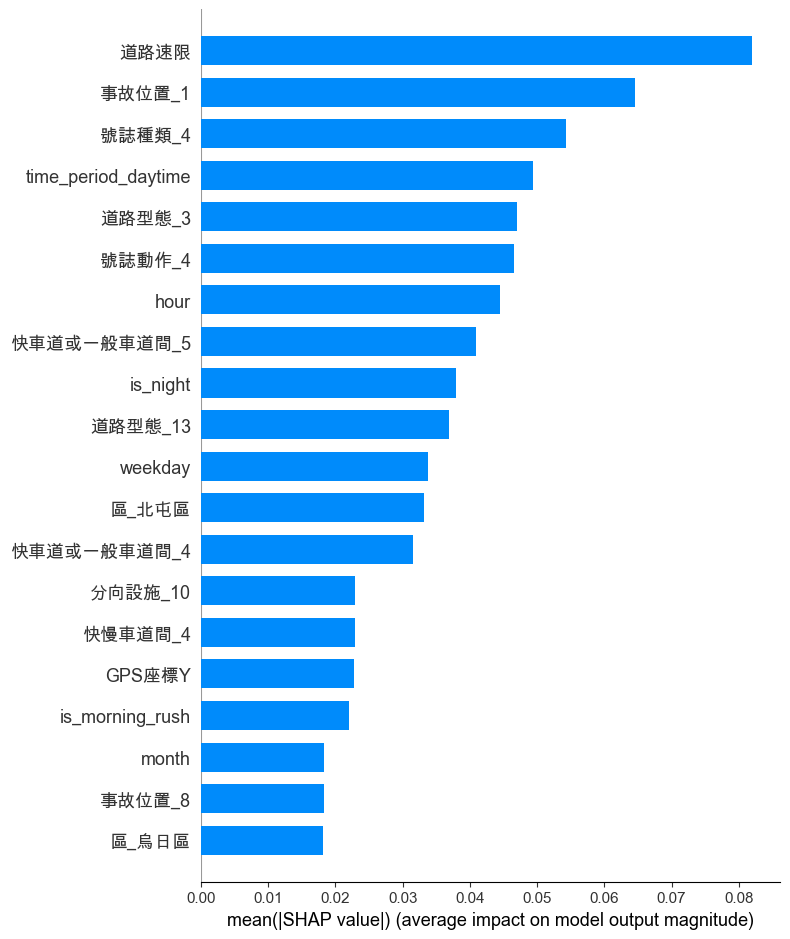

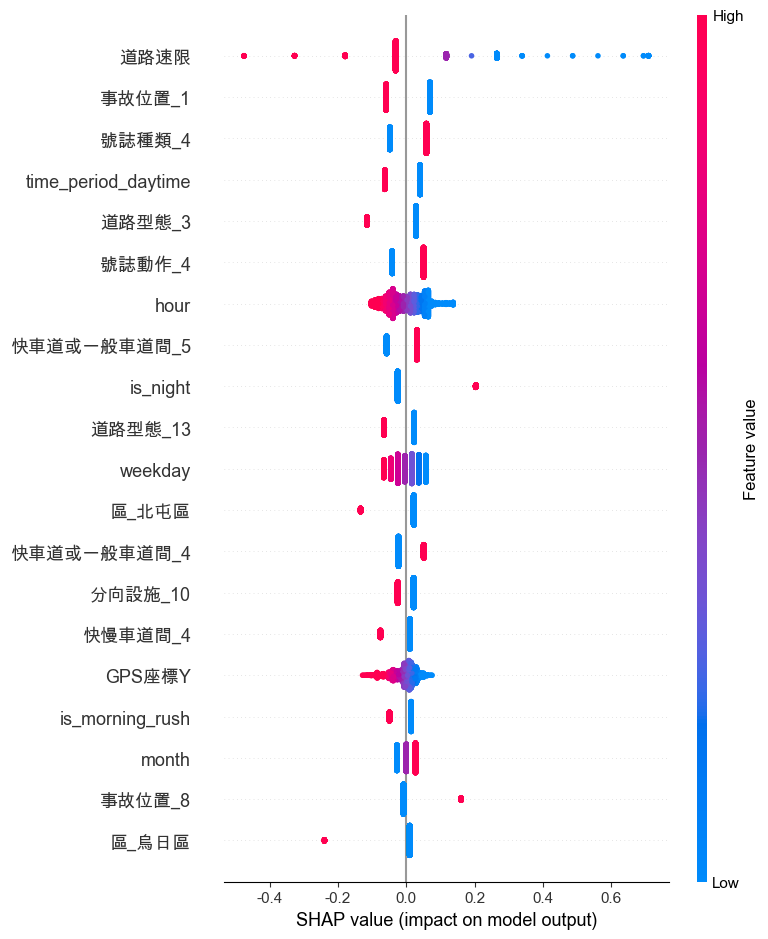

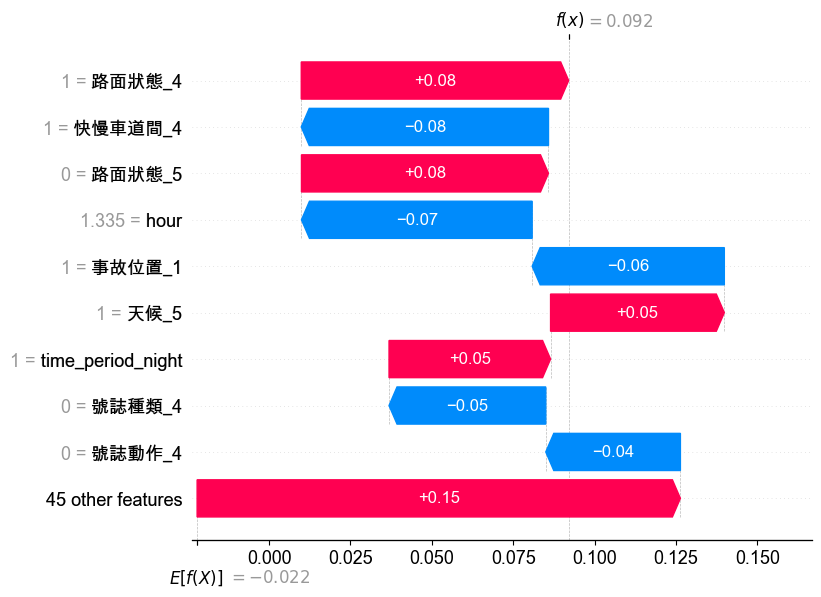

In [11]:
import shap

# ── 1. 從 Pipeline 取出已訓練好的前處理器與 LR 模型 ────────
fitted_preprocess = best_lr_model.named_steps['preprocess']
fitted_lr = best_lr_model.named_steps['model']

# ColumnTransformer 的輸出順序：先 continuous_cols，再 passthrough 欄位
passthrough_cols = [col for col in X_train.columns if col not in continuous_cols]
lr_shap_features = continuous_cols + passthrough_cols

# 將 X_train / X_test 轉成 LR 真正吃進去的標準化後資料
X_train_lr_shap = pd.DataFrame(
    fitted_preprocess.transform(X_train),
    columns=lr_shap_features,
    index=X_train.index
)

X_test_lr_shap = pd.DataFrame(
    fitted_preprocess.transform(X_test),
    columns=lr_shap_features,
    index=X_test.index
)

# ── 2. 建立 SHAP Explainer ────────────────────────────────
explainer = shap.LinearExplainer(fitted_lr, X_train_lr_shap)
shap_values = explainer.shap_values(X_test_lr_shap)

# ── 3. Summary Bar Plot：全局特徵重要性 ──────────────────
shap.summary_plot(
    shap_values,
    X_test_lr_shap,
    feature_names=lr_shap_features,
    plot_type='bar',
    show=True
)

# ── 4. Beeswarm Plot：特徵影響方向 ───────────────────────
shap.summary_plot(
    shap_values,
    X_test_lr_shap,
    feature_names=lr_shap_features,
    show=True
)

# ── 5. Waterfall Plot：單一致命案例解析 ──────────────────
fatal_idx = np.where(y_test.values == 1)[0][0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[fatal_idx],
        base_values=explainer.expected_value,
        data=X_test_lr_shap.iloc[fatal_idx],
        feature_names=lr_shap_features
    )
)

## Random forest
### step2 : modeling

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ── 定義模型（RF 不需要標準化，直接用原始 X_train）────────
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# ── 10-fold 交叉驗證 ───────────────────────────────────────
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_recall = cross_val_score(
    rf_model, X_train, y_train,
    cv=cv, scoring='recall', n_jobs=-1
)
cv_f1 = cross_val_score(
    rf_model, X_train, y_train,
    cv=cv, scoring='f1', n_jobs=-1
)

print("【預設參數】交叉驗證結果：")
print(f"  Recall : {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
print(f"  F1     : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

# ── 訓練完整模型 ───────────────────────────────────────────
rf_model.fit(X_train, y_train)
print("\n模型訓練完成！")

【預設參數】交叉驗證結果：
  Recall : 0.5634 ± 0.0192
  F1     : 0.5908 ± 0.0156

模型訓練完成！


### step3 : Hyperparameter 

In [13]:
# 超參數

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# ── 定義 Random Forest 模型 ───────────────────────────────
rf_model = RandomForestClassifier(
    random_state=42
)

# ── 定義參數網格 ──────────────────────────────────────────
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None]
}

# ── Grid Search：用 F1-score 作為挑選標準 ───────────────────
grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=10,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

# ── 整理結果 ──────────────────────────────────────────────
results_rf = pd.DataFrame(grid_search_rf.cv_results_)

summary_rf = results_rf[[
    'param_n_estimators',
    'param_max_depth',
    'param_min_samples_split',
    'param_class_weight',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]]

summary_rf = summary_rf.rename(columns={
    'param_n_estimators': 'n_estimators',
    'param_max_depth': 'max_depth',
    'param_min_samples_split': 'min_samples_split',
    'param_class_weight': 'class_weight',
    'mean_test_score': 'F1-score（平均）',
    'std_test_score': 'F1-score（標準差）',
    'rank_test_score': '排名'
})

summary_rf['F1-score（平均）'] = summary_rf['F1-score（平均）'].round(4)
summary_rf['F1-score（標準差）'] = summary_rf['F1-score（標準差）'].round(4)

print("Random Forest Grid Search 結果（以 F1-score 作為標準）：")
print(summary_rf.sort_values('排名').to_string(index=False))

print("\n最佳參數：")
print(grid_search_rf.best_params_)
print(f"最佳 F1-score（CV）：{grid_search_rf.best_score_:.4f}")

Fitting 10 folds for each of 54 candidates, totalling 540 fits
Random Forest Grid Search 結果（以 F1-score 作為標準）：
 n_estimators  max_depth  min_samples_split class_weight  F1-score（平均）  F1-score（標準差）  排名
          300          4                  2          NaN        0.7173         0.0013   1
          300          4                 10          NaN        0.7173         0.0013   2
          300          4                  5          NaN        0.7172         0.0013   3
          200          4                 10          NaN        0.7172         0.0016   4
          200          4                  2          NaN        0.7170         0.0017   5
          200          4                  5          NaN        0.7170         0.0015   6
          100          4                  2          NaN        0.7168         0.0018   7
          100          4                  5          NaN        0.7165         0.0018   8
          100          4                 10          NaN        0.7163         0

In [14]:
# 用最佳參數定義並訓練模型 

best_rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=4,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

best_rf_model.fit(X_train, y_train)
print("RF 最終模型訓練完成！")

RF 最終模型訓練完成！


### step4: Evaluation

Random Forest 評估結果：
Accuracy  : 0.5674
Precision : 0.6212
Recall    : 0.5829
F1-score  : 0.6014
ROC-AUC   : 0.5917
PR-AUC    : 0.6380

Classification Report:
              precision    recall  f1-score   support

         非致命       0.51      0.55      0.53      1687
          致命       0.62      0.58      0.60      2146

    accuracy                           0.57      3833
   macro avg       0.56      0.57      0.56      3833
weighted avg       0.57      0.57      0.57      3833


Confusion Matrix:
[[ 924  763]
 [ 895 1251]]


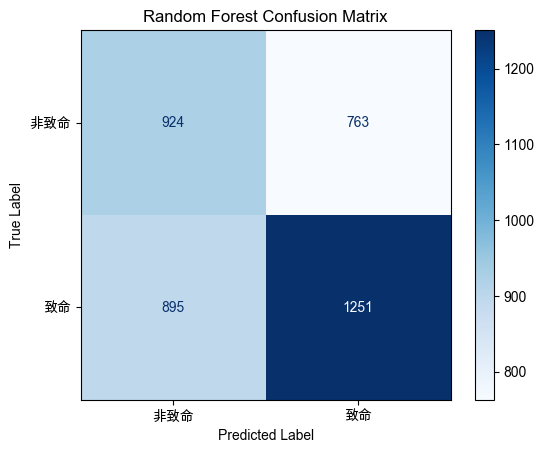

In [15]:
# ── Random Forest 最終模型評估 ─────────────────────

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)

# 預測類別與機率
y_pred_rf = best_rf_model.predict(X_test)
y_prob_rf = best_rf_model.predict_proba(X_test)[:, 1]

# 儲存 RF 評估指標
rf_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf, zero_division=0),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-score': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_prob_rf),
    'PR-AUC': average_precision_score(y_test, y_prob_rf)
}

print("Random Forest 評估結果：")
for metric, value in rf_metrics.items():
    print(f"{metric:<10}: {value:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['非致命', '致命']
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


# ── Random Forest Confusion Matrix ─────────────────────

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['非致命', '致命']
)

disp_rf.plot(cmap='Blues', values_format='d')

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [16]:
# ── Logistic Regression vs Random Forest 自動比較表 ───────

comparison_df = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'Random Forest': rf_metrics
})

comparison_df['Better Model'] = comparison_df.apply(
    lambda row: 'LR' if row['Logistic Regression'] > row['Random Forest'] else 'RF',
    axis=1
)

print("\nLogistic Regression vs Random Forest 比較表：")
print(comparison_df.round(4))


Logistic Regression vs Random Forest 比較表：
           Logistic Regression  Random Forest Better Model
Accuracy                0.5638         0.5674           RF
Precision               0.6299         0.6212           LR
Recall                  0.5354         0.5829           RF
F1-score                0.5788         0.6014           RF
ROC-AUC                 0.5947         0.5917           LR
PR-AUC                  0.6341         0.6380           RF


In [17]:
# RF 輸出機率值

rf_prob = best_rf_model.predict_proba(X_test)[:, 1]

rf_result = pd.DataFrame({
    'y_true': y_test.values,
    'y_prob': rf_prob
})

print(rf_result.head(10))
rf_result.to_csv('rf_prob.csv', index=False)

   y_true    y_prob
0       0  0.534048
1       1  0.466590
2       0  0.470269
3       0  0.504450
4       1  0.458479
5       0  0.519656
6       0  0.463368
7       0  0.453932
8       0  0.538922
9       0  0.534978


In [18]:
threshold = 0.4

y_pred_rf_custom = (rf_prob >= threshold).astype(int)

print(f"門檻：{threshold}")
print(classification_report(y_test, y_pred_rf_custom, target_names=['non-fatal', 'fatal']))

門檻：0.4
              precision    recall  f1-score   support

   non-fatal       1.00      0.00      0.00      1687
       fatal       0.56      1.00      0.72      2146

    accuracy                           0.56      3833
   macro avg       0.78      0.50      0.36      3833
weighted avg       0.75      0.56      0.40      3833



In [19]:
# 尋找最佳門檻值

print(f"{'='*55}")
print("RF 門檻掃描")
print(f"{'='*55}")
print(f"{'Threshold':>10}  {'Recall':>8}  {'Precision':>10}  {'F1':>8}")
print(f"{'-'*55}")
for t in thresholds:
    y_pred_t = (rf_prob >= t).astype(int)
    r = recall_score(y_test, y_pred_t)
    p = precision_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    print(f"{t:>10.2f}  {r:>8.4f}  {p:>10.4f}  {f1:>8.4f}")

RF 門檻掃描
 Threshold    Recall   Precision        F1
-------------------------------------------------------
      0.10    1.0000      0.5599    0.7178
      0.15    1.0000      0.5599    0.7178
      0.20    1.0000      0.5599    0.7178
      0.25    1.0000      0.5599    0.7178
      0.30    1.0000      0.5599    0.7178
      0.35    1.0000      0.5600    0.7180
      0.40    1.0000      0.5600    0.7180
      0.45    0.9716      0.5658    0.7151
      0.50    0.5829      0.6212    0.6014
      0.55    0.1421      0.6932    0.2359
      0.60    0.0205      0.7458    0.0399
      0.65    0.0019      0.8000    0.0037
      0.70    0.0000      0.0000    0.0000
      0.75    0.0000      0.0000    0.0000
      0.80    0.0000      0.0000    0.0000
      0.85    0.0000      0.0000    0.0000


### step5: Interpretation

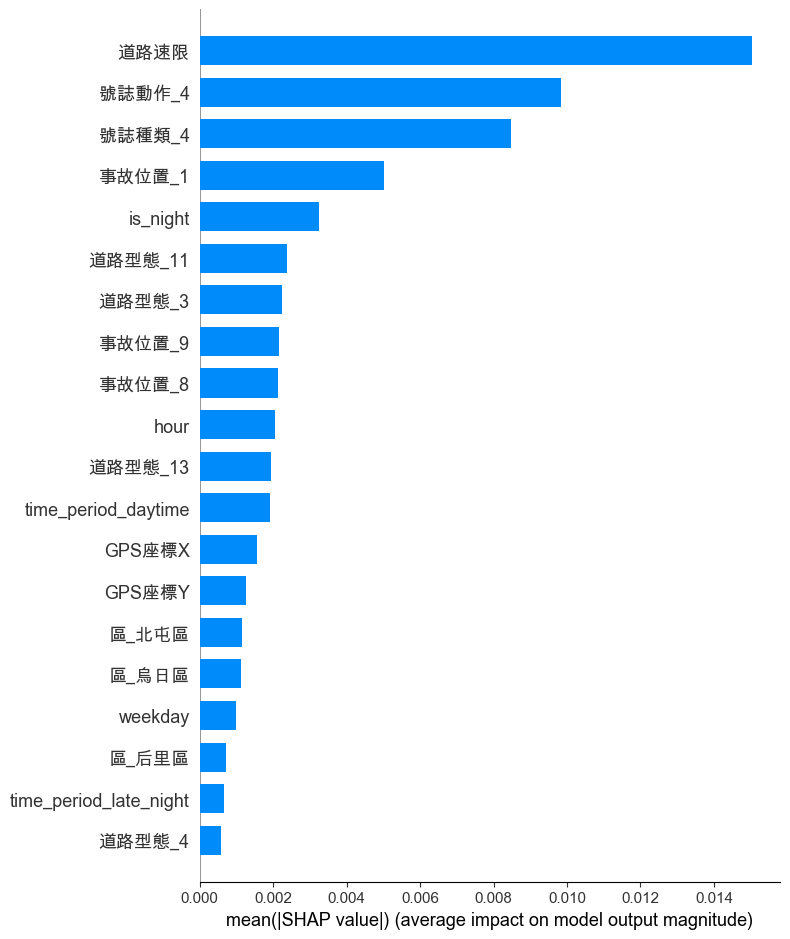

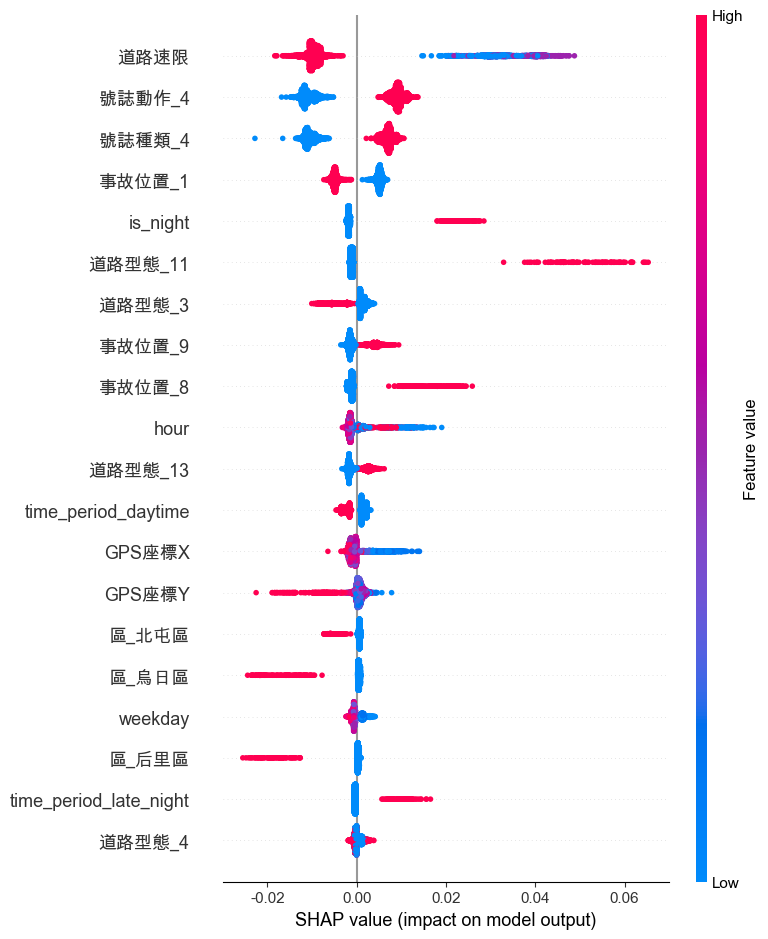

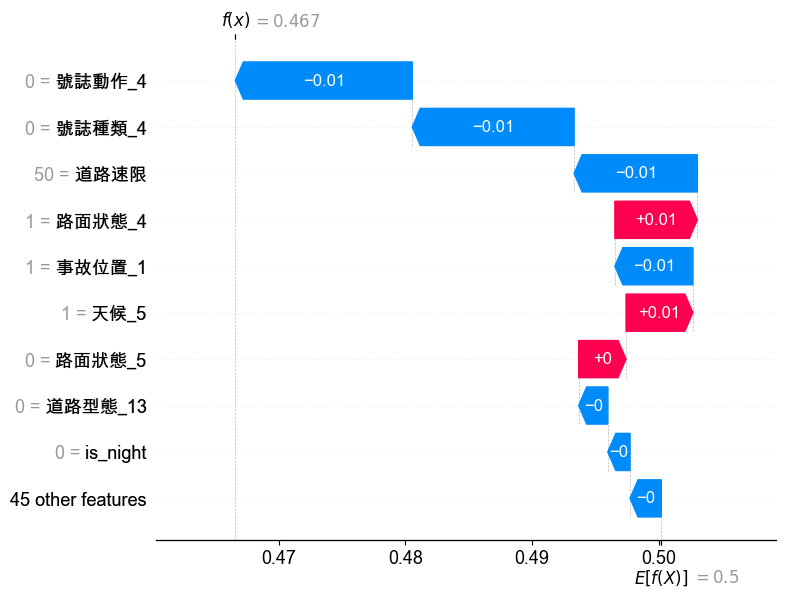

In [20]:
import shap
import numpy as np

# ── 1. 建立 SHAP Explainer（RF 用 TreeExplainer）─────────
explainer_rf = shap.TreeExplainer(best_rf_model)
shap_values_rf = explainer_rf.shap_values(X_test)

# TreeExplainer 對二元分類會回傳 list，取 class=1（致命）
shap_vals = shap_values_rf[:, :, 1] if shap_values_rf.ndim == 3 else shap_values_rf[1]

# ── 2. Summary Bar Plot：全局特徵重要性 ──────────────────
shap.summary_plot(
    shap_vals, X_test,
    feature_names=features,
    plot_type='bar',
    show=True
)

# ── 3. Beeswarm Plot：特徵影響方向 ───────────────────────
shap.summary_plot(
    shap_vals, X_test,
    feature_names=features,
    show=True
)

# ── 4. Waterfall Plot：單一致命案例解析 ──────────────────
fatal_idx = np.where(y_test.values == 1)[0][0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_vals[fatal_idx],
        base_values=explainer_rf.expected_value[1],
        data=X_test.iloc[fatal_idx],
        feature_names=features
    )
)